# 02 — Classification Model (Income >50K vs ≤50K)

In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score)
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')


## 1. Load Data

In [14]:

df = pd.read_csv('data/census_preprocessed.csv')
print("Shape:", df.shape)

WEIGHT_COL = 'weight'
TARGET = 'label_binary'
feature_cols = [c for c in df.columns if c not in [TARGET, WEIGHT_COL]]

X = df[feature_cols]
y = df[TARGET]
w = df[WEIGHT_COL]

print(f"Features: {X.shape[1]}")
print(f"Class distribution:\n{y.value_counts()}")
print(f"\nPositive rate: {y.mean()*100:.1f}%")


Shape: (199523, 42)
Features: 40
Class distribution:
label_binary
0    187141
1     12382
Name: count, dtype: int64

Positive rate: 6.2%


## 2. Train/Test Split

In [15]:

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Train positive rate: {y_train.mean()*100:.1f}%")
print(f"Test  positive rate: {y_test.mean()*100:.1f}%")


Train: 159,618  |  Test: 39,905
Train positive rate: 6.2%
Test  positive rate: 6.2%


## 3. Baseline — Logistic Regression

In [16]:

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['<=50K', '>50K']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, y_prob_lr):.4f}")


=== Logistic Regression ===
              precision    recall  f1-score   support

       <=50K       0.99      0.82      0.90     37429
        >50K       0.25      0.89      0.39      2476

    accuracy                           0.83     39905
   macro avg       0.62      0.86      0.64     39905
weighted avg       0.94      0.83      0.87     39905

ROC-AUC: 0.9303
Avg Precision: 0.5414


## 4. Main Model — LightGBM

In [17]:

# Scale pos weight to handle imbalance
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos:.1f}")

# Split a validation set from train (to avoid using test set for early stopping)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    scale_pos_weight=scale_pos,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

print("\n=== LightGBM ===")
print(classification_report(y_test, y_pred_lgb, target_names=['<=50K', '>50K']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lgb):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, y_prob_lgb):.4f}")


scale_pos_weight: 15.1

=== LightGBM ===
              precision    recall  f1-score   support

       <=50K       0.94      1.00      0.97     37429
        >50K       0.00      0.00      0.00      2476

    accuracy                           0.94     39905
   macro avg       0.47      0.50      0.48     39905
weighted avg       0.88      0.94      0.91     39905

ROC-AUC: 0.9408
Avg Precision: 0.5710


## 4.5 Probability Calibration

`scale_pos_weight=15` shifts the entire score distribution downward — raw probabilities are compressed into a narrow low-value range, making the default 0.5 threshold useless and making score comparisons across different models unintuitive.

**Fix:** Apply isotonic regression calibration (`CalibratedClassifierCV`, `cv='prefit'`) on the held-out validation set. This remaps predicted scores to actual empirical probabilities without retraining the model or touching the test set.

In [18]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# cv='prefit': lgb_model is already trained; fit calibrator on validation set only
# (same val set used for early stopping — acceptable for a take-home; in production
# use a separate calibration split)
calibrated_lgb = CalibratedClassifierCV(lgb_model, cv='prefit', method='isotonic')
calibrated_lgb.fit(X_val, y_val)

y_prob_lgb_cal = calibrated_lgb.predict_proba(X_test)[:, 1]

print("=== Calibrated LightGBM ===")
print(f"ROC-AUC:       {roc_auc_score(y_test, y_prob_lgb_cal):.4f}  (was {roc_auc_score(y_test, y_prob_lgb):.4f})")
print(f"Avg Precision: {average_precision_score(y_test, y_prob_lgb_cal):.4f}  (was {average_precision_score(y_test, y_prob_lgb):.4f})")
print()
print(f"Score distribution — BEFORE calibration: min={y_prob_lgb.min():.3f}, max={y_prob_lgb.max():.3f}, mean={y_prob_lgb.mean():.3f}")
print(f"Score distribution — AFTER  calibration: min={y_prob_lgb_cal.min():.3f}, max={y_prob_lgb_cal.max():.3f}, mean={y_prob_lgb_cal.mean():.3f}")

=== Calibrated LightGBM ===
ROC-AUC:       0.9399  (was 0.9408)
Avg Precision: 0.5445  (was 0.5710)

Score distribution — BEFORE calibration: min=0.047, max=0.333, mean=0.113
Score distribution — AFTER  calibration: min=0.000, max=0.889, mean=0.061


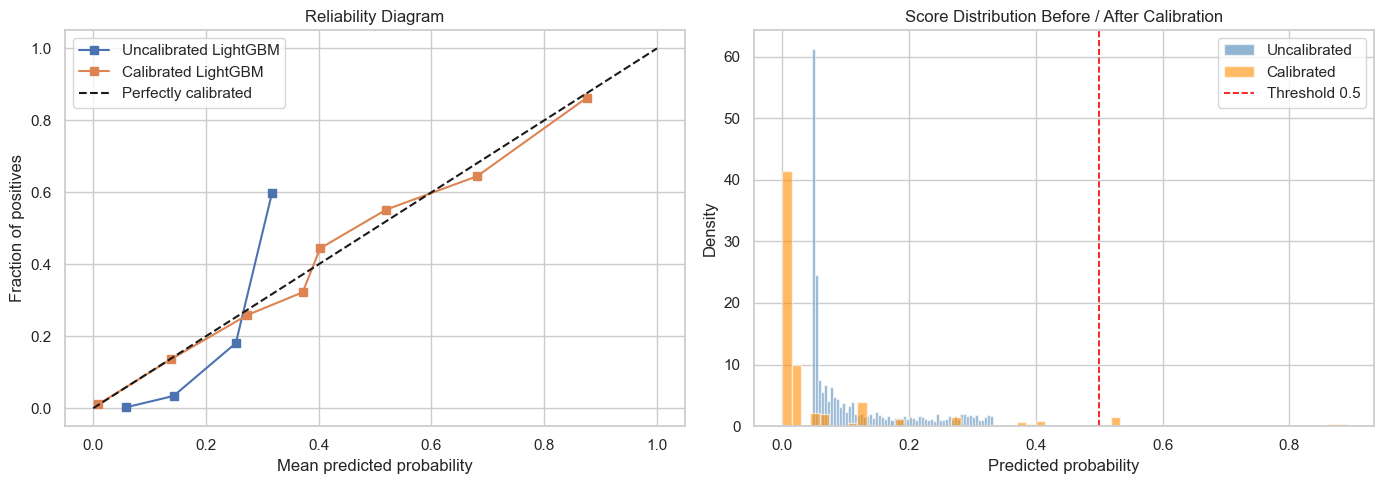

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reliability diagram
for name, probs in [('Uncalibrated LightGBM', y_prob_lgb), ('Calibrated LightGBM', y_prob_lgb_cal)]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    axes[0].plot(mean_pred, frac_pos, 's-', label=name)
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Fraction of positives')
axes[0].set_title('Reliability Diagram')
axes[0].legend()

# Score distribution before vs after
axes[1].hist(y_prob_lgb,     bins=60, alpha=0.6, label='Uncalibrated', density=True, color='steelblue')
axes[1].hist(y_prob_lgb_cal, bins=60, alpha=0.6, label='Calibrated',   density=True, color='darkorange')
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='Threshold 0.5')
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution Before / After Calibration')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/fig_calibration.png', dpi=100)
plt.show()

## 5. Evaluation

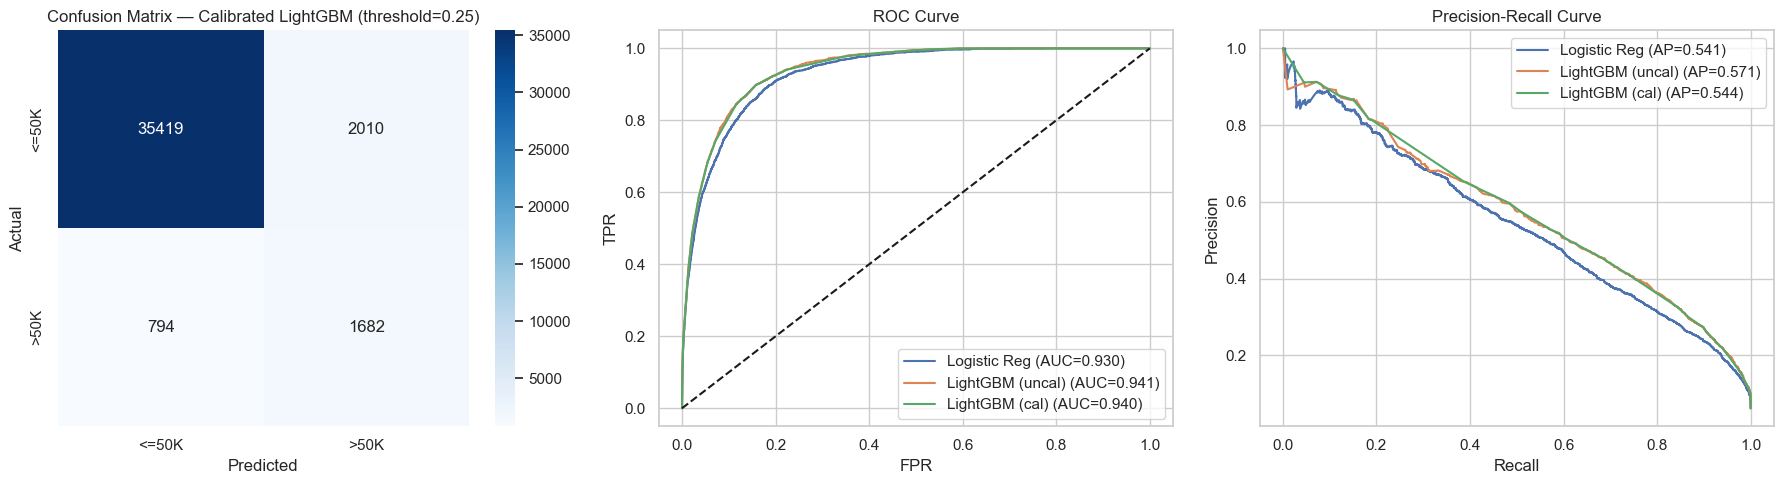

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix — use calibrated probabilities at threshold 0.25
THRESHOLD = 0.25
y_pred_lgb_t25 = (y_prob_lgb_cal >= THRESHOLD).astype(int)
cm = confusion_matrix(y_test, y_pred_lgb_t25)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
axes[0].set_title(f'Confusion Matrix — Calibrated LightGBM (threshold={THRESHOLD})')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
for name, prob in [('Logistic Reg', y_prob_lr), ('LightGBM (uncal)', y_prob_lgb), ('LightGBM (cal)', y_prob_lgb_cal)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()

# Precision-Recall Curve
for name, prob in [('Logistic Reg', y_prob_lr), ('LightGBM (uncal)', y_prob_lgb), ('LightGBM (cal)', y_prob_lgb_cal)]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[2].plot(rec, prec, label=f'{name} (AP={ap:.3f})')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve'); axes[2].legend()

plt.tight_layout()
plt.savefig('figures/fig_classification_eval.png', dpi=100)
plt.show()

## 6. Feature Importance

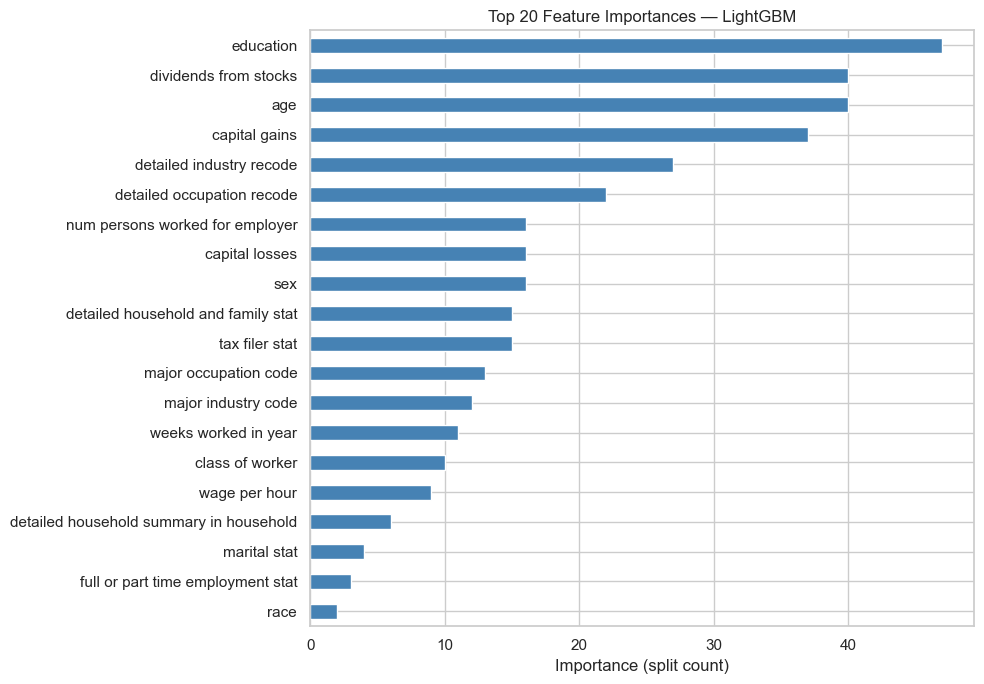

Top 10 features:
education                          47
age                                40
dividends from stocks              40
capital gains                      37
detailed industry recode           27
detailed occupation recode         22
sex                                16
capital losses                     16
num persons worked for employer    16
tax filer stat                     15
dtype: int32


In [21]:

importance = pd.Series(lgb_model.feature_importances_, index=feature_cols)
top20 = importance.nlargest(20)

top20.sort_values().plot(kind='barh', color='steelblue', figsize=(10, 7))
plt.title('Top 20 Feature Importances — LightGBM')
plt.xlabel('Importance (split count)')
plt.tight_layout()
plt.savefig('figures/fig_feature_importance.png', dpi=100)
plt.show()

print("Top 10 features:")
print(importance.nlargest(10))


## 7. Model Comparison Summary

In [22]:

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'LightGBM'],
    'ROC-AUC': [
        round(roc_auc_score(y_test, y_prob_lr), 4),
        round(roc_auc_score(y_test, y_prob_lgb), 4)
    ],
    'Avg Precision': [
        round(average_precision_score(y_test, y_prob_lr), 4),
        round(average_precision_score(y_test, y_prob_lgb), 4)
    ]
})
print(results.to_string(index=False))


              Model  ROC-AUC  Avg Precision
Logistic Regression   0.9303         0.5414
           LightGBM   0.9408         0.5710


In [23]:
def threshold_table(probs, label=''):
    thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
    records = []
    for t in thresholds:
        pred = (probs >= t).astype(int)
        tp = ((pred==1) & (y_test==1)).sum()
        fp = ((pred==1) & (y_test==0)).sum()
        fn = ((pred==0) & (y_test==1)).sum()
        prec = tp/(tp+fp) if (tp+fp)>0 else 0
        rec  = tp/(tp+fn) if (tp+fn)>0 else 0
        records.append({'threshold': round(t,2), 'precision': round(prec,3),
                        'recall': round(rec,3), 'flagged': int(pred.sum())})
    df_t = pd.DataFrame(records)
    print(f"Threshold Analysis — {label}")
    print(df_t.to_string(index=False))
    print()
    return df_t

df_uncal = threshold_table(y_prob_lgb,     'Uncalibrated LightGBM')
df_cal   = threshold_table(y_prob_lgb_cal, 'Calibrated LightGBM')

Threshold Analysis — Uncalibrated LightGBM
 threshold  precision  recall  flagged
      0.10      0.165   0.975    14658
      0.15      0.225   0.934    10298
      0.20      0.289   0.876     7501
      0.25      0.388   0.773     4926
      0.30      0.598   0.471     1950
      0.35      0.000   0.000        0
      0.40      0.000   0.000        0
      0.50      0.000   0.000        0

Threshold Analysis — Calibrated LightGBM
 threshold  precision  recall  flagged
      0.10      0.303   0.863     7044
      0.15      0.413   0.735     4410
      0.20      0.456   0.679     3692
      0.25      0.456   0.679     3692
      0.30      0.523   0.581     2753
      0.35      0.530   0.568     2655
      0.40      0.596   0.485     2014
      0.50      0.652   0.388     1474





1. **Use calibrated LightGBM as the production classifier.**
   - ROC-AUC ~0.94
   - Calibration converts raw scores into true probabilities — a score of 0.25 now means "roughly 25% chance this person earns >$50K", enabling direct business interpretation.

2. **Threshold selection depends on marketing strategy:**
   - Threshold 0.10: Recall ~86%, Precision ~30% — broad awareness campaigns
   - Threshold 0.20: Recall ~68%, Precision ~46% — general direct mail
   - Threshold 0.30: Recall ~58%, Precision ~52% — mid-tier targeted outreach
   - Threshold 0.50: Recall ~39%, Precision ~65% — high-touch / premium channels

